# Credit Risk Prediction Project

## Introduction and Problem Statement

Credit Risk Prediction is used to determine whether a loan applicant is likely to repay a loan or default on it. In this project machine learning techniques are used to analyze applicant information such as income, education, loan amount, and credit history. The main objective is to build a model that can predict loan status accurately and help financial institutions make better lending decisions.

**This is a binary classification problem:**
- 1 is Loan Approved / No Default
- 0 is Loan Rejected / Default Risk


In [19]:
#Import Libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Dataset Load and Understanding.
df = pd.read_csv("train.csv")
df.head()

df.shape
df.info()
df.describe()

#Data Cleaning:
df.isnull().sum()

df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

le = LabelEncoder()

for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = le.fit_transform(df[col])

#Model Training.
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


# Exploratory Data Analysis EDA.

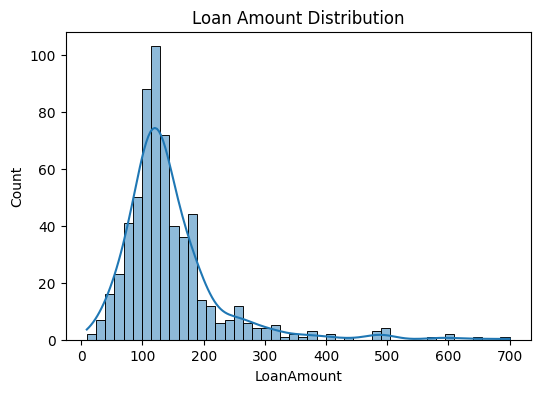

In [20]:
#Loan Amount Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

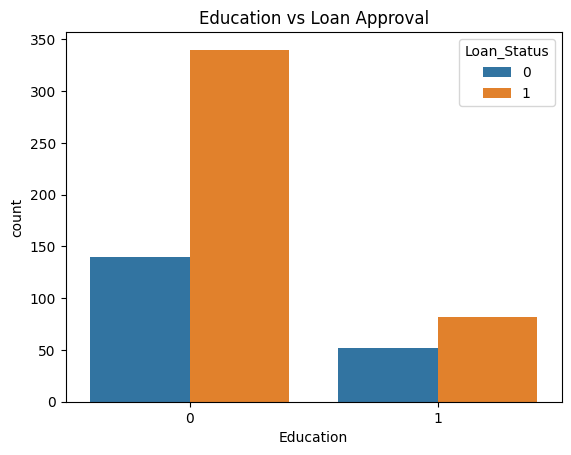

In [21]:
#Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education vs Loan Approval")
plt.show()

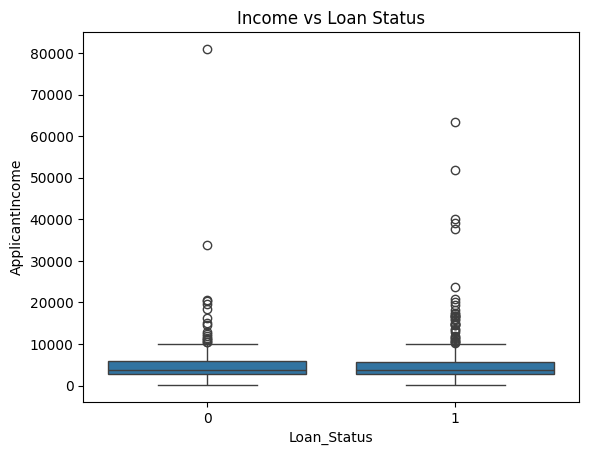

In [22]:
#Income vs Loan Status
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title("Income vs Loan Status")
plt.show()

Logistic Regression Accuracy: 0.7886178861788617


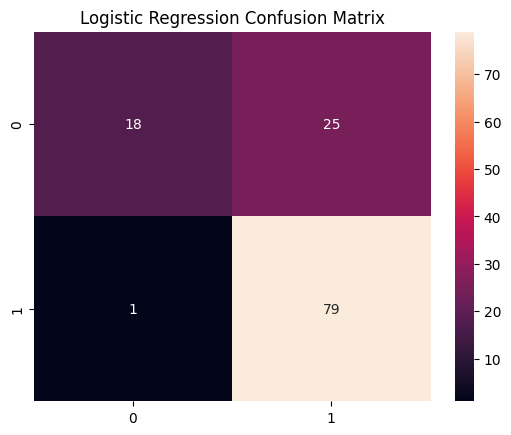

In [23]:
#Logistic Regression.
lr_model = LogisticRegression(max_iter=5000, solver='liblinear')  
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Decision Tree Accuracy: 0.6910569105691057


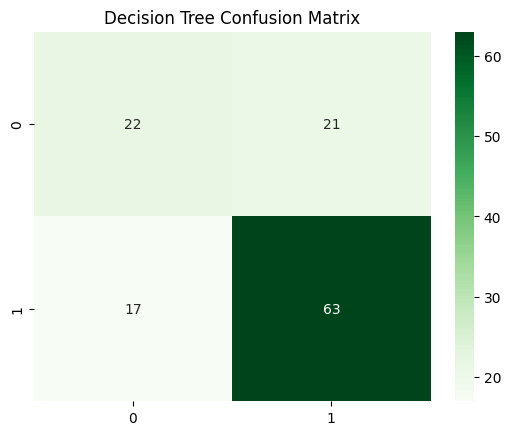

In [16]:
#Decision Tree.
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens')
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [24]:
#Model Comparison.
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.7886178861788617
Decision Tree Accuracy: 0.6910569105691057


# Conclusion

In this project the loan dataset was cleaned and analyzed using Exploratory Data Analysis (EDA). Logistic Regression and Decision Tree models were trained to predict loan status. The models were evaluated using accuracy and a confusion matrix. The results show that machine learning can be used effectively for credit risk prediction and loan approval decisions.
